# ISO 20414:2020 — Test 4: Movement around a corner

20 occupants uniformly distributed in a 2 m x 4 m area at one end of an L-shaped hallway, pre-evacuation time 0, walking speed 1 m/s (ISO 20414:2020 Table 5). They must navigate the corner without penetrating the boundaries.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 07 July 2026, 18:56 CEST


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pedpy
from shapely.geometry import Point

from jupedsim_scenarios import load_scenario, run_scenario

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Load and run

In [4]:
SCENARIO_ZIP = Path("scenario_files") / "Iso-04-corner.zip"
scenario = load_scenario(str(SCENARIO_ZIP))
print(scenario.summary())
result = run_scenario(scenario, seed=42)
walkable = scenario.walkable_polygon
df = result.trajectory_dataframe()

Scenario: /Users/chraibi/workspace/PedestrianDynamics/jupedsim-web-community/standards/iso/scenario_files/Iso-04-corner.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      120s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      1
  Agents:        ~20
  Journey elems: 2
  Route:         1 distribution, 0 checkpoint, 1 exit
  Sequence:      jps-distributions_0 -> jps-exits_0
    jps-distributions_0: 20 agents


## Boundary-penetration check

In [5]:
walkable_with_tol = walkable.buffer(0.001)
outside = []
for _, row in df.iterrows():
    if not walkable_with_tol.contains(Point(row.x, row.y)):
        outside.append((int(row.id), int(row.frame), float(row.x), float(row.y)))
print(f'{len(outside)} / {len(df)} trajectory points outside walkable area')

0 / 3861 trajectory points outside walkable area


## Flow rates into and out of the corner

Agents travel along the horizontal leg (crossing x = 6) into the corner, then up the vertical leg (crossing y = 6) out of it. ISO suggests comparing the flow entering the corner (horizontal leg, x = 6) and leaving it (vertical leg, y = 6) to check whether the corner causes a bottleneck.

In [6]:
def crossings(df, axis, value, rate):
    ts = []
    for _, sub in df.sort_values(['id', 'frame']).groupby('id'):
        coord = sub[axis]
        before = sub[coord < value]; after = sub[coord >= value]
        if len(before) and len(after):
            ts.append(after.iloc[0].frame / rate)
    return sorted(ts)
enter = crossings(df, 'x', 6.0, result.frame_rate)
leave = crossings(df, 'y', 6.0, result.frame_rate)
def flow(ts):
    return (len(ts) - 1) / (ts[-1] - ts[0]) if len(ts) >= 2 and ts[-1] > ts[0] else float('nan')
print(f'flow entering corner (x=6): {flow(enter):.3f} p/s ({len(enter)} agents)')
print(f'flow leaving corner  (y=6): {flow(leave):.3f} p/s ({len(leave)} agents)')

flow entering corner (x=6): 2.000 p/s (20 agents)
flow leaving corner  (y=6): 1.338 p/s (20 agents)


## Plot trajectories

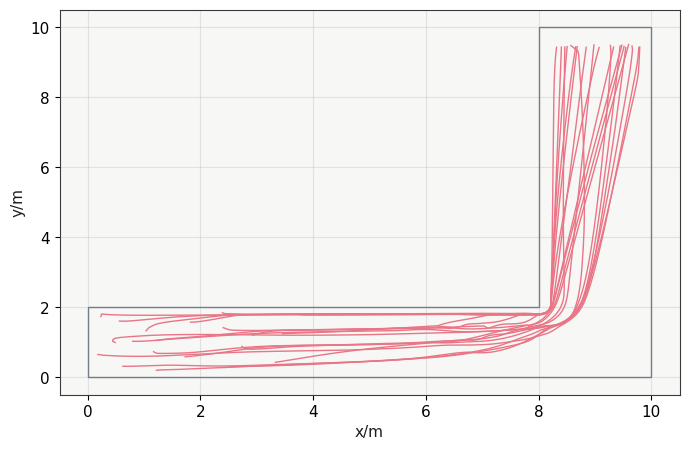

In [7]:
traj = pedpy.TrajectoryData(df[['id', 'frame', 'x', 'y']].copy(), frame_rate=result.frame_rate)
wa = pedpy.WalkableArea(walkable)
pedpy.plot_trajectories(walkable_area=wa, traj=traj)
plt.show()

## Acceptance

In [8]:
assert len(outside) == 0, outside[:5]
assert result.agents_remaining == 0, result.agents_remaining
print(f'evacuation time = {result.evacuation_time:.2f} s')
result.cleanup()

evacuation time = 26.39 s


1